# UM171-to-UM729 conversion experiment (EryPro/MgkPro)

Reads the annotation config, loads the forward models, and runs the UM171-to-UM729 protocol conversion predictions for the EryPro and late_MgkPro populations.

In [464]:
import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


Read annotation file 

In [465]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [466]:
# Paths to load 
generated_csvs_paths = {"EryPro": "../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus/filtered/filtered_candidates_EryPro_with_cell_count_pred.csv", 
                        "MgkPro": "../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus/filtered/filtered_candidates_late_MgkPro_with_cell_count_pred.csv"}

In [467]:
def conversion(df, conversion_type: str = "um171_to_um729"):  
    df_converted = df.copy()
    if conversion_type == "um171_to_um729":
        # df_converted["um729_[µm]"] = df_converted["um171_[nm]"] * 18.87
        df_converted["um729_[µm]"] = 1.75
        df_converted["um171_[nm]"] = 0
    elif conversion_type == "um729_to_um171":
        # df_converted["um171_[nm]"] = df_converted["um729_[µm]"] * 0.053
        df_converted["um171_[nm]"] = 1120
        df_converted["um729_[µm]"] = 0
    else:
        raise NotImplementedError
    return df_converted

In [468]:
generated_csvs = {}

for cell_type in generated_csvs_paths:
    generated_csvs[cell_type] = pd.read_csv(generated_csvs_paths[cell_type], index_col=0)
    generated_csvs[cell_type] = generated_csvs[cell_type].reset_index(drop=True)

## Conversions late_MgkPro

In [469]:
MgkPro_df = generated_csvs["MgkPro"].loc[:, protocol_cols]

In [470]:
# Some solutions require a conversion, some others require another 
MgkPro_df["um171_to_um729"] = True 

In [471]:
MgkPro_df.loc[MgkPro_df["um171_[nm]"] < 1, "um171_to_um729"] = False

In [472]:
MgkPro_df_um171_to_um729 = MgkPro_df[MgkPro_df["um171_to_um729"]]

In [473]:
MgkPro_df_um729_to_um171 = MgkPro_df[~MgkPro_df["um171_to_um729"]]

Just consider the conversion um171 to um729 cause the others have none, basically

In [474]:
MgkPro_df = MgkPro_df.loc[MgkPro_df_um171_to_um729.index]

In [475]:
MgkPro_df_um171_to_um729

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,um171_to_um729
0,0.000000,0.000000,0.000000,66.515010,0.000000,0.000000,110.476974,0.000000,0.000000,0.000000,19.016068,13.254240,True
1,0.000000,0.000000,0.000000,66.178680,0.000000,0.000000,110.445885,0.000000,0.000000,0.000000,18.985062,13.272754,True
2,0.477673,0.053988,0.049927,60.553190,0.000000,0.469665,87.517780,0.000000,0.000000,0.000000,17.692993,12.970562,True
3,0.000000,0.000000,0.198734,58.962450,0.000000,0.000000,104.683525,0.039752,0.025231,0.000000,18.468860,13.129865,True
4,0.000000,0.000000,0.000000,66.541990,0.000000,0.000000,110.506004,0.000000,0.000000,0.000000,19.036990,13.244378,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,9.068640,1.336970,44.911472,14.614872,0.000000,0.000090,4.944443,0.000000,0.000000,0.000000,13.723815,12.470534,True
154,9.122126,1.342038,45.923992,14.417890,0.000000,0.000381,4.927684,0.000000,0.000000,0.000000,13.585310,12.524385,True
166,0.658013,1.647250,0.505135,7.642544,0.026098,17.951242,1.208067,0.433440,0.269714,0.629084,9.645871,17.071468,True
167,9.072524,1.336987,45.029930,14.632685,0.000719,0.000010,4.958318,0.000000,0.000000,0.000000,13.813409,12.480652,True


In [476]:
MgkPro_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,um171_to_um729
0,0.000000,0.000000,0.000000,66.515010,0.000000,0.000000,110.476974,0.000000,0.000000,0.000000,19.016068,13.254240,True
1,0.000000,0.000000,0.000000,66.178680,0.000000,0.000000,110.445885,0.000000,0.000000,0.000000,18.985062,13.272754,True
2,0.477673,0.053988,0.049927,60.553190,0.000000,0.469665,87.517780,0.000000,0.000000,0.000000,17.692993,12.970562,True
3,0.000000,0.000000,0.198734,58.962450,0.000000,0.000000,104.683525,0.039752,0.025231,0.000000,18.468860,13.129865,True
4,0.000000,0.000000,0.000000,66.541990,0.000000,0.000000,110.506004,0.000000,0.000000,0.000000,19.036990,13.244378,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,9.068640,1.336970,44.911472,14.614872,0.000000,0.000090,4.944443,0.000000,0.000000,0.000000,13.723815,12.470534,True
154,9.122126,1.342038,45.923992,14.417890,0.000000,0.000381,4.927684,0.000000,0.000000,0.000000,13.585310,12.524385,True
166,0.658013,1.647250,0.505135,7.642544,0.026098,17.951242,1.208067,0.433440,0.269714,0.629084,9.645871,17.071468,True
167,9.072524,1.336987,45.029930,14.632685,0.000719,0.000010,4.958318,0.000000,0.000000,0.000000,13.813409,12.480652,True


In [477]:
converted_mgkpro = conversion(MgkPro_df_um171_to_um729, "um171_to_um729")

In [478]:
converted_mgkpro

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,um171_to_um729
0,0.000000,0.000000,0.000000,0,1.75,0.000000,110.476974,0.000000,0.000000,0.000000,19.016068,13.254240,True
1,0.000000,0.000000,0.000000,0,1.75,0.000000,110.445885,0.000000,0.000000,0.000000,18.985062,13.272754,True
2,0.477673,0.053988,0.049927,0,1.75,0.469665,87.517780,0.000000,0.000000,0.000000,17.692993,12.970562,True
3,0.000000,0.000000,0.198734,0,1.75,0.000000,104.683525,0.039752,0.025231,0.000000,18.468860,13.129865,True
4,0.000000,0.000000,0.000000,0,1.75,0.000000,110.506004,0.000000,0.000000,0.000000,19.036990,13.244378,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,9.068640,1.336970,44.911472,0,1.75,0.000090,4.944443,0.000000,0.000000,0.000000,13.723815,12.470534,True
154,9.122126,1.342038,45.923992,0,1.75,0.000381,4.927684,0.000000,0.000000,0.000000,13.585310,12.524385,True
166,0.658013,1.647250,0.505135,0,1.75,17.951242,1.208067,0.433440,0.269714,0.629084,9.645871,17.071468,True
167,9.072524,1.336987,45.029930,0,1.75,0.000010,4.958318,0.000000,0.000000,0.000000,13.813409,12.480652,True


In [479]:
converted_mgkpro = np.log1p(converted_mgkpro.loc[:, protocol_cols])
MgkPro_df = np.log1p(MgkPro_df.loc[:, protocol_cols])

## Conversions late_MgkPro

In [480]:
EryPro_df.loc[:, ["um171_[nm]", "um729_[µm]"]]

,um171_[nm],um729_[µm]
0,0.778159,0.001869
1,0.462721,0.000000
2,0.463143,0.026038
3,1.001505,0.120525
4,0.751308,0.032074
...,...,...
195,0.000000,0.000000
196,0.059582,0.015941
197,0.000000,0.000000
198,1.532609,0.007413


In [481]:
for val in EryPro_df["um171_[nm]"]:
    print(val)

0.7781591615380283
0.462720581754834
0.463142921220006
1.0015045310323456
0.7513078435088131
1.0533800568059053
0.13783536001701432
0.7707432243144411
0.2246282307163931
0.7697398096842158
0.5082057907465505
1.0227950823241634
0.6988526864532401
1.2675598386411646
0.6864945728744992
0.6806592157240499
0.7319465299719675
0.32765413505519686
0.3242187025098259
0.6409651553544735
0.943288710142854
1.081711643778241
0.7457382925197534
0.7893849576801607
0.712195754237269
0.6061858204878409
0.6352166600198175
0.9567113659445664
0.6947272544883639
0.0
0.7255836024578798
0.6346698258028269
0.9298099653162286
0.6300329419480564
0.7428180871146406
0.4240766267253967
0.0
1.2599390410889508
1.006952143101439
0.0
0.7393207635648273
0.0
0.8460605833845878
0.8215078594164734
0.7495729375953585
0.3069906342190605
0.775500542857522
1.039489348715515
0.6776053571994647
0.5936904386581329
0.6853981483502467
0.5667989172231164
0.2376539652306825
0.6461680867416766
0.6995852880746594
0.0
0.765117004851991

In [482]:
EryPro_df = generated_csvs["EryPro"].loc[:, protocol_cols]

In [483]:
# EryPro_df = EryPro_df[np.logical_or(EryPro_df["um171_[nm]"]>0,
#                                     )]

In [484]:
# # Some solutions require a conversion, some others require another 
# EryPro_df["um171_to_um729"] = True 

In [485]:
# EryPro_df.loc[EryPro_df["um171_[nm]"] < 1, "um171_to_um729"] = False

In [486]:
converted_erypro = EryPro_df.copy()
converted_erypro["um171_[nm]"] = 0
converted_erypro["um729_[µm]"] = 0

In [487]:
converted_erypro = np.log1p(converted_erypro)
EryPro_df = np.log1p(EryPro_df)

## Run predictions 

In [488]:
BASE_DIR = "../../../../../.."

from hydra import initialize, compose
import os
import sys
import logging
from labcompass.constants import DataFields
import torch.nn.functional as F


sys.path.insert(0, os.path.join(BASE_DIR, "shared_utils"))

from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn, 
    compute_exploitation_score, 
    compute_exploration_score, 
    compute_weighted_uncertainty_score, 
    compute_sequential_local_penalization
)

Load models 

In [489]:
CONFIG_PATH = "../../../../../../inverse/loss_guidance/config"

with initialize(config_path=CONFIG_PATH, version_base=None):
    base_cfg = compose(
        config_name="run_inverse",
        overrides=["paths=bloodplus_fm"]
    )

In [490]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [491]:
base_cfg["paths"]

{'perturbation_prediction_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl', 'ct_classifier_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/easy-monkey-341_TargetPredictionModel.pkl', 'prior_flow_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_matching/2026-04-04_10-19-42/woven-dawn-22_FlowMatchingWithScore.pkl', 'prior_flow_map_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_map/2026-04-13_11-57-30/copper-thunder-24_FlowMap.pkl', 'dump_dir': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse'}

In [492]:
forward_model, (_, target_prediction_model) = get_forward_model(base_cfg, logger=logger)

2026-05-07 05:04:01,625 - INFO - Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
2026-05-07 05:06:22,799 - INFO - Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
   

Prepare label encoder for plots 

In [493]:
# Prepare label encoder
logger.info("Preparing labels")   
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 

2026-05-07 05:06:25,359 - INFO - Preparing labels


In [494]:
labels_conversion = ["after conversion", "before conversion",]

## Predict EryPro

In [498]:
pred_df_erypro = []

with torch.no_grad():
    for label_converson, df in zip(labels_conversion, [EryPro_df, converted_erypro]):
        # Get candidates 
        X_candidates =  torch.from_numpy(
            df.values
        ).float().to(
            forward_model.forward_model.device
        )
        # Predict 
        X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
        condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
        batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}
        forward_out = forward_model.predict(
            batch_dict,
            no_grad=True,
            fix_noise=False,
            num_time_steps=100
        )

        y_pred = F.softmax(forward_out["target_prediction_data"]["cell_type"], dim=-1).mean(1)
        pred_df = pd.DataFrame(y_pred.cpu().numpy(), columns=classes)
        pred_df_erypro.append(pred_df)

In [499]:
pred_df_erypro = [df.melt() for df in pred_df_erypro]
pred_df_erypro[1]["dataset_type"] = "Convert TPO to butyzamide"
pred_df_erypro[0]["dataset_type"] = "Original generated"

pred_df_erypro = pd.concat(pred_df_erypro)

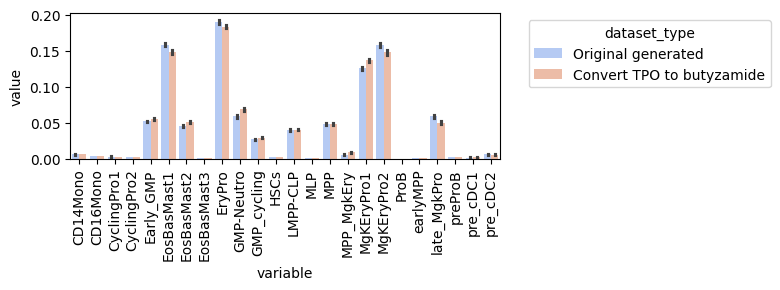

In [500]:
plt.figure(figsize=(8,3))
ax = sns.barplot(
    data=pred_df_erypro,
    x="variable",
    y="value",
    hue="dataset_type",
    palette="coolwarm"
)

plt.xticks(rotation=90)

# Place legend outside
ax.legend(title="dataset_type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Predict MgkPro

In [501]:
converted_mgkpro

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
0,0.000000,0.000000,0.000000,0.0,1.011601,0.000000,4.713818,0.000000,0.000000,0.000000,2.996535,2.657054
1,0.000000,0.000000,0.000000,0.0,1.011601,0.000000,4.713539,0.000000,0.000000,0.000000,2.994985,2.658352
2,0.390469,0.052581,0.048720,0.0,1.011601,0.385034,4.483203,0.000000,0.000000,0.000000,2.928149,2.636952
3,0.000000,0.000000,0.181266,0.0,1.011601,0.000000,4.660449,0.038982,0.024918,0.000000,2.968816,2.648291
4,0.000000,0.000000,0.000000,0.0,1.011601,0.000000,4.714078,0.000000,0.000000,0.000000,2.997580,2.656362
...,...,...,...,...,...,...,...,...,...,...,...,...
146,2.309426,0.848855,3.826715,0.0,1.011601,0.000090,1.782457,0.000000,0.000000,0.000000,2.689466,2.600505
154,2.314724,0.851021,3.848529,0.0,1.011601,0.000381,1.779634,0.000000,0.000000,0.000000,2.680015,2.604494
166,0.505620,0.973521,0.408883,0.0,1.011601,2.941869,0.792117,0.360077,0.238792,0.488018,2.365172,2.894334
167,2.309811,0.848862,3.829292,0.0,1.011601,0.000010,1.784788,0.000000,0.000000,0.000000,2.695533,2.601255


In [502]:
pred_df_MgkPro = []

with torch.no_grad():
    for label_converson, df in zip(labels_conversion, [converted_mgkpro, MgkPro_df]):
        # Get candidates 
        X_candidates =  torch.from_numpy(
            df.values
        ).float().to(
            forward_model.forward_model.device
        )
        # Predict 
        X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
        condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
        batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}
        forward_out = forward_model.predict(
            batch_dict,
            no_grad=True,
            fix_noise=False,
            num_time_steps=100
        )

        y_pred = F.softmax(forward_out["target_prediction_data"]["cell_type"], dim=-1).mean(1)
        pred_df = pd.DataFrame(y_pred.cpu().numpy(), columns=classes)
        pred_df_MgkPro.append(pred_df)

In [503]:
pred_df_MgkPro = [df.melt() for df in pred_df_MgkPro]
pred_df_MgkPro[0]["dataset_type"] = "After conversion"
pred_df_MgkPro[1]["dataset_type"] = "Before conversion"

pred_df_MgkPro = pd.concat(pred_df_MgkPro)

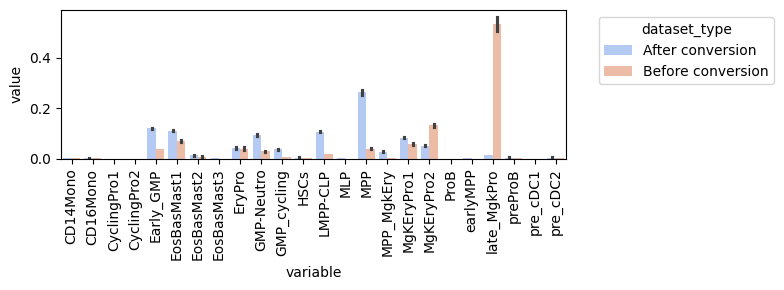

In [504]:
plt.figure(figsize=(8,3))
ax = sns.barplot(
    data=pred_df_MgkPro,
    x="variable",
    y="value",
    hue="dataset_type",
    palette="coolwarm"
)

plt.xticks(rotation=90)

# Place legend outside
ax.legend(title="dataset_type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()